# Notebook 03_B: Extended Model Comparison

This notebook extends the baseline comparison with three additional machine learning models:

- XGBoost
- Support Vector Machine
- LightGBM

The full comparison contains six classifiers:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. XGBoost
5. Support Vector Machine
6. LightGBM

Only the **training set** is used in this notebook.

All models are evaluated using the same five fold stratified cross validation procedure, with preprocessing fitted inside each fold.

No held out test results are used for model comparison or finalist selection here.

Because the thesis prioritises identifying students who are genuinely at risk, recall is considered alongside F1 and PR AUC.

## 1. Imports and project paths

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

RANDOM_STATE = 42
CV_RANDOM_STATE = 2026

CURRENT_DIR = Path.cwd()
PROJECT_DIR = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

DATA_DIR = (
    PROJECT_DIR
    / "data"
    / "processed"
    / "ml_ready"
)

RESULTS_DIR = (
    PROJECT_DIR
    / "results"
    / "model_comparison"
)

FIGURES_DIR = (
    PROJECT_DIR
    / "results"
    / "figures"
)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)

Project directory: c:\Users\israa.tajaldin\OneDrive - Bahrain Polytechnic\Group Group IT9099 - Israa Tajaldin - General\04_Project_Notebooks


## 2. Load training data only

In [2]:
X_train = pd.read_pickle(
    DATA_DIR / "X_train_raw.pkl"
)

y_train = pd.read_pickle(
    DATA_DIR / "y_train.pkl"
)

print("Training shape:", X_train.shape)
print("Target shape:", y_train.shape)
print("At risk percentage:", round(float(y_train.mean() * 100), 2))

assert len(X_train) == len(y_train)

Training shape: (3008, 24)
Target shape: (3008,)
At risk percentage: 24.8


In [3]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", round(scale_pos_weight, 3))

scale_pos_weight: 3.032


## 3. Define predictors and cross validation

The current Notebook 02 feature set is used unchanged.

Gender is not part of the model input.

The held out test set is not loaded in this notebook.

In [4]:
CATEGORICAL_FEATURES = [
    "programme_or_school",
    "year_level",
    "previous_academic_standing",
]

NUMERIC_FEATURES = [
    column
    for column in X_train.columns
    if column not in CATEGORICAL_FEATURES
]

print("Numeric predictors:", len(NUMERIC_FEATURES))
print("Categorical predictors:", len(CATEGORICAL_FEATURES))
print("Total raw predictors:", X_train.shape[1])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=CV_RANDOM_STATE,
)

Numeric predictors: 21
Categorical predictors: 3
Total raw predictors: 24


## 4. Preprocessing

Numeric predictors:

- median imputation
- standard scaling

Categorical predictors:

- most frequent imputation
- one hot encoding

The same preprocessing structure is used for all six models so the comparison is consistent.

In [5]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median"),
    ),
    (
        "scaler",
        StandardScaler(),
    ),
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent"),
    ),
    (
        "encoder",
        OneHotEncoder(handle_unknown="ignore"),
    ),
])

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        NUMERIC_FEATURES,
    ),
    (
        "categorical",
        categorical_pipeline,
        CATEGORICAL_FEATURES,
    ),
])

## 5. Define the six comparison models

These are reasonable comparison configurations only.

Extensive tuning is not performed here.

In [6]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),

    "SVM": CalibratedClassifierCV(
    estimator=SVC(
        C=1.0,
        kernel="rbf",
        gamma="scale",
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    method="sigmoid",
    cv=5,
    ensemble=False,
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbosity=-1,
    ),
}

print("Models:", list(models.keys()))

Models: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'SVM', 'LightGBM']


## 6. Five fold stratified cross validation

In [7]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
}

rows = []

for model_name, model in models.items():

    pipeline = Pipeline([
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "model",
            model,
        ),
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
    )

    rows.append({
        "model": model_name,
        "accuracy": scores["test_accuracy"].mean(),
        "precision": scores["test_precision"].mean(),
        "recall": scores["test_recall"].mean(),
        "f1": scores["test_f1"].mean(),
        "roc_auc": scores["test_roc_auc"].mean(),
        "pr_auc": scores["test_pr_auc"].mean(),
        "f1_std": scores["test_f1"].std(),
        "recall_std": scores["test_recall"].std(),
    })

comparison = pd.DataFrame(rows)

comparison = (
    comparison
    .sort_values(
        ["f1",  "pr_auc","recall"],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    comparison.round(4)
)

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,f1_std,recall_std
0,Random Forest,0.9013,0.7605,0.8835,0.8163,0.9578,0.8773,0.0243,0.0412
1,XGBoost,0.9013,0.7628,0.8741,0.8142,0.9599,0.8919,0.0145,0.0361
2,LightGBM,0.8993,0.7773,0.8338,0.8038,0.9570,0.8873,0.0168,0.0400
3,SVM,0.8996,0.8020,0.7910,0.7959,0.9530,0.8611,0.0183,0.0348
4,Decision Tree,0.8843,0.7112,0.8995,0.7942,0.9228,0.8209,0.0186,0.0244
5,Logistic Regression,0.8836,0.7258,0.8539,0.7845,0.9440,0.8494,0.0091,0.0197


## 7. Comparison figure

Only one figure is saved from this notebook.

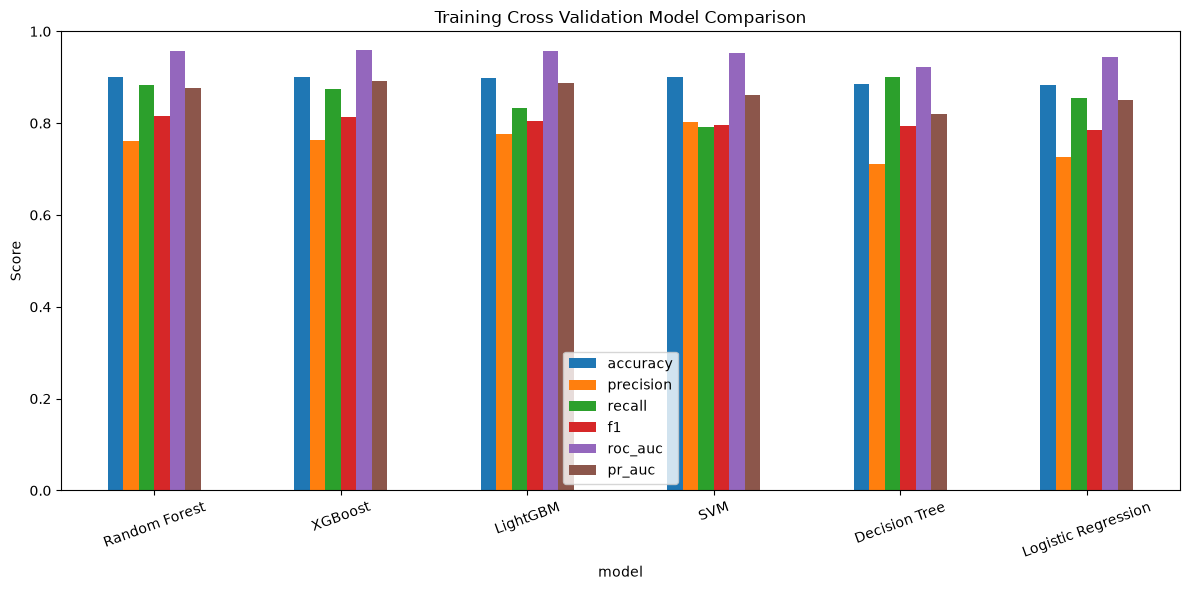

Saved: c:\Users\israa.tajaldin\OneDrive - Bahrain Polytechnic\Group Group IT9099 - Israa Tajaldin - General\04_Project_Notebooks\results\figures\model_comparison_cv.png


In [8]:
plot_data = (
    comparison[
        [
            "model",
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "pr_auc",
        ]
    ]
    .set_index("model")
)

axis = plot_data.plot(
    kind="bar",
    figsize=(12, 6),
)

axis.set_title(
    "Training Cross Validation Model Comparison"
)

axis.set_ylabel(
    "Score"
)

axis.set_ylim(
    0,
    1,
)

plt.xticks(rotation=20)
plt.tight_layout()

figure_file = (
    FIGURES_DIR
    / "model_comparison_cv.png"
)

plt.savefig(
    figure_file,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", figure_file)

## 8. Save only the comparison results


In [9]:
results_file = (
    RESULTS_DIR
    / "model_comparison_cv.csv"
)

comparison.to_csv(
    results_file,
    index=False,
)

print("Saved:", results_file)

Saved: c:\Users\israa.tajaldin\OneDrive - Bahrain Polytechnic\Group Group IT9099 - Israa Tajaldin - General\04_Project_Notebooks\results\model_comparison\model_comparison_cv.csv


## Notebook 03_B complete